In [50]:
# importing different packages
import geopandas as gpd
import pandas as pd

In [51]:
county_dataframe = pd.read_pickle("county_data.pkl")

# this is the data that is going to be used to cluster the counties
clustering_data = county_dataframe.drop(columns=['FIPS', 'State', 'Area_Name'])
print(clustering_data.columns)

clustering_data.fillna(clustering_data.mean(), inplace=True)  # Replace NaN with column mean
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)
clustering_data_scaled = pd.DataFrame(clustering_data_scaled)
print(type(clustering_data_scaled))
num = 8

Index(['2023 Rural-urban Continuum Code',
       'Less than a high school diploma, 2018-22',
       'High school diploma only, 2018-22',
       'Some college or associate's degree, 2018-22',
       'Bachelor's degree or higher, 2018-22',
       'Percent of adults with less than a high school diploma, 2018-22',
       'Percent of adults with a high school diploma only, 2018-22',
       'Percent of adults completing some college or associate's degree, 2018-22',
       'Percent of adults with a bachelor's degree or higher, 2018-22',
       'POP_ESTIMATE_2023', 'BIRTHS_2023', 'NATURAL_CHG_2023',
       'INTERNATIONAL_MIG_2023', 'DOMESTIC_MIG_2023', 'NET_MIG_2023',
       'RESIDUAL_2023', 'GQ_ESTIMATES_2023', 'R_BIRTH_2023', 'R_DEATH_2023',
       'R_NATURAL_CHG_2023', 'R_INTERNATIONAL_MIG_2023', 'R_DOMESTIC_MIG_2023',
       'R_NET_MIG_2023', 'POVALL_2021', 'CI90LBALL_2021', 'CI90UBALL_2021',
       'PCTPOVALL_2021', 'CI90LBALLP_2021', 'CI90UBALLP_2021', 'POV017_2021',
       'CI90LB017_20

In [52]:
import umap
from sklearn.cluster import KMeans

# UMAP dimensionality reduction
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_data = umap_reducer.fit_transform(clustering_data_scaled)

# Clustering the UMAP-reduced data with k-means
kmeans = KMeans(n_clusters=num, random_state=42, n_init=10)
umap_clusters = kmeans.fit_predict(umap_data)

# Add cluster labels to the dataframe
clustering_data_scaled['UMAP_Cluster'] = umap_clusters


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [53]:
from sklearn.decomposition import PCA

# PCA dimensionality reduction
pca = PCA(n_components=0.9, random_state=42)
clustering_data_scaled.columns = clustering_data_scaled.columns.astype(str)
pca_data = pca.fit_transform(clustering_data_scaled)

# Clustering the PCA-reduced data with k-means
kmeans = KMeans(n_clusters=num, random_state=42, n_init=10)
pca_clusters = kmeans.fit_predict(pca_data)

# Add cluster labels to the dataframe
clustering_data_scaled['PCA_Cluster'] = pca_clusters


In [54]:
from sklearn.manifold import TSNE

# t-SNE dimensionality reduction
tsne = TSNE(n_components=3, random_state=42)
tsne_data = tsne.fit_transform(clustering_data_scaled)

# Clustering the t-SNE-reduced data with k-means
kmeans = KMeans(n_clusters=num, random_state=42, n_init=10)
tsne_clusters = kmeans.fit_predict(tsne_data)

# Add cluster labels to the dataframe
clustering_data_scaled['tSNE_Cluster'] = tsne_clusters


In [55]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

kmeans = KMeans(n_clusters=num, random_state=42)
clustering_data_scaled['Cluster'] = kmeans.fit_predict(clustering_data_scaled)

rf = RandomForestClassifier(random_state=42)
rf.fit(clustering_data_scaled.drop(columns=['Cluster']), clustering_data_scaled['Cluster'])

importances = rf.feature_importances_
top_features_idx = np.argsort(importances)[-5:]  # Indices of top 5 features
top_features = clustering_data_scaled.iloc[:, top_features_idx]

kmeans = KMeans(n_clusters=num, random_state=42)
rf_clusters = kmeans.fit_predict(top_features)

clustering_data_scaled['RF_Cluster'] = rf_clusters

# Using PCA for dimensionality reduction of full dataset for visualization
pca_full = PCA(n_components=0.9)
pca_full_components = pca_full.fit_transform(clustering_data_scaled.drop(columns=['Cluster', 'RF_Cluster']))

# Reduce dimensions to 2D for visualization
pca = PCA(n_components=0.9)
pca_components = pca.fit_transform(top_features)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [56]:
# k-means clustering
kmeans = KMeans(n_clusters=num, random_state=42, n_init=10)
kmeans_clusters = kmeans.fit_predict(clustering_data_scaled)

# Add cluster labels to the dataframe
clustering_data_scaled['KMeans_Cluster'] = kmeans_clusters


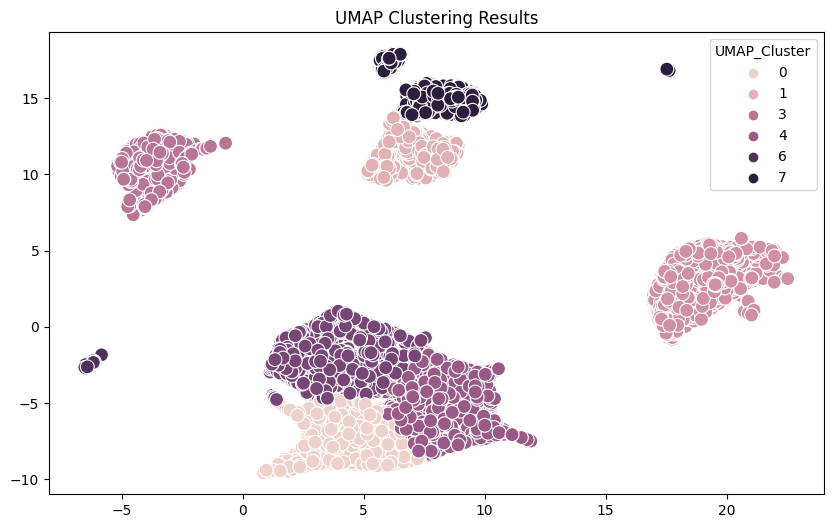

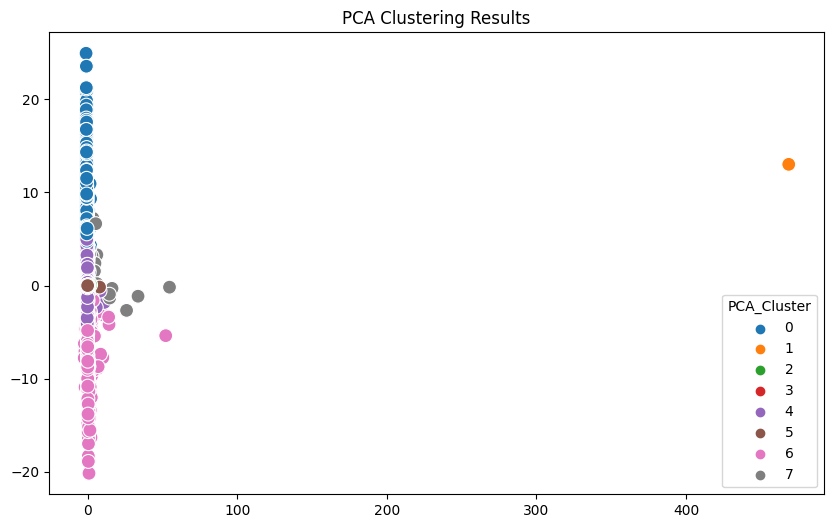

[0.5612482  0.18843075 0.15247894]


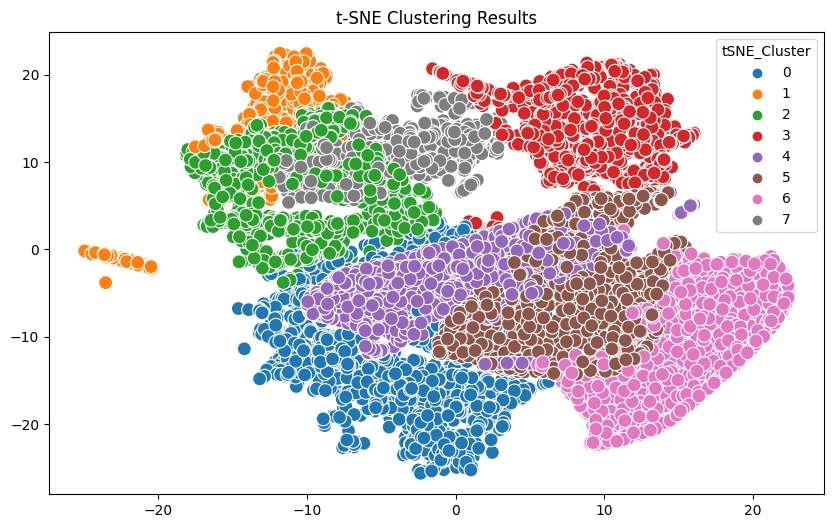

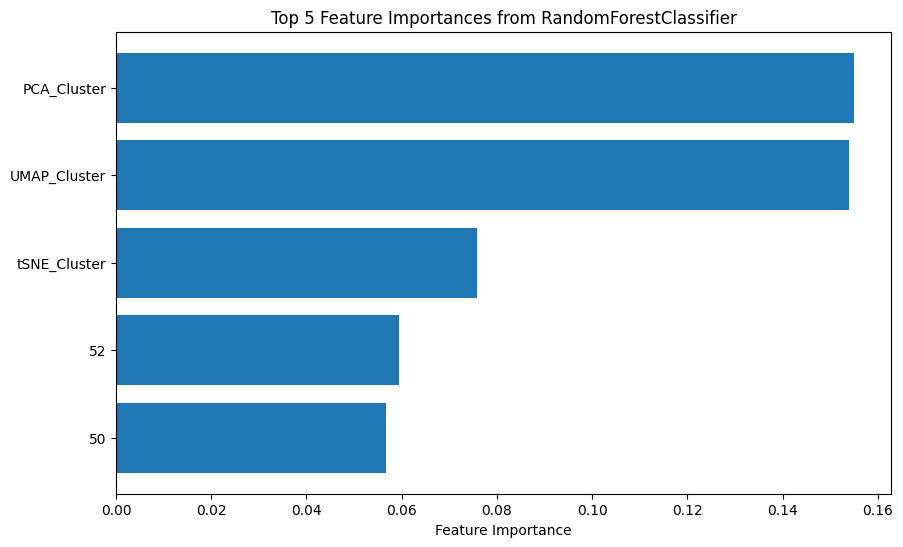

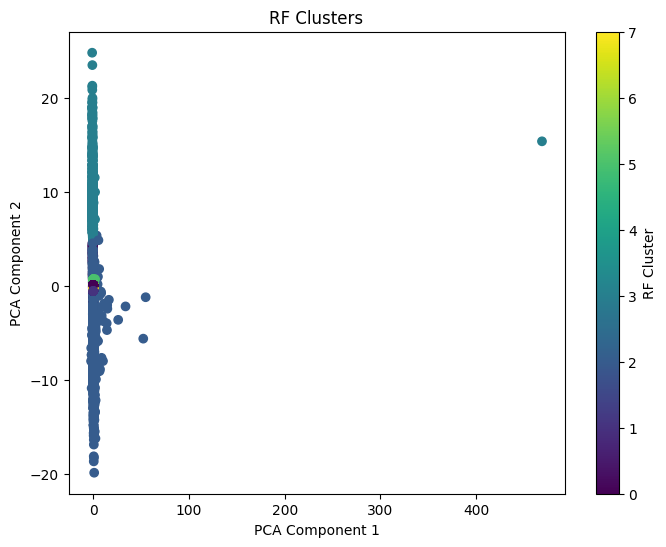

"\n# Plotting the clusters with K-means\nplt.figure(figsize=(8, 6))\nplt.scatter(pca_components[:, 0], pca_components[:, 1], c=clustering_data_scaled['KMeans_Cluster'], cmap='viridis')\nplt.title('KMeans Clusters with Top 5 Features')\nplt.xlabel('PCA Component 1')\nplt.ylabel('PCA Component 2')\nplt.colorbar(label='Cluster')\nplt.show()\n"

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# UMAP
plt.figure(figsize=(10, 6))
sns.scatterplot(x=umap_data[:, 0], y=umap_data[:, 1], hue=clustering_data_scaled['UMAP_Cluster'], s=100)
plt.title('UMAP Clustering Results')
plt.show()

# PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=clustering_data_scaled['PCA_Cluster'], palette='tab10', s=100)
plt.title('PCA Clustering Results')
plt.show()

print(pca.explained_variance_ratio_)

# t-SNE
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_data[:, 0], y=tsne_data[:, 1], hue=clustering_data_scaled['tSNE_Cluster'], palette='tab10', s=100)
plt.title('t-SNE Clustering Results')
plt.show()

# RandomForest
plt.figure(figsize=(10, 6))
plt.barh(clustering_data_scaled.drop(columns=['Cluster']).columns[top_features_idx], importances[top_features_idx])
plt.xlabel('Feature Importance')
plt.title('Top 5 Feature Importances from RandomForestClassifier')
plt.show()


# Plotting the RF clusters
plt.figure(figsize=(8, 6))
plt.scatter(pca_full_components[:, 0], pca_full_components[:, 1], c=clustering_data_scaled['RF_Cluster'], cmap='viridis')
plt.title('RF Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='RF Cluster')
plt.show()

"""
# Plotting the clusters with K-means
plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=clustering_data_scaled['KMeans_Cluster'], cmap='viridis')
plt.title('KMeans Clusters with Top 5 Features')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()
"""